<a href="https://colab.research.google.com/github/tanvighorpade/edaexample/blob/main/store_salesEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv("store_sales.csv")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


In [13]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Category,0
ItemPurchased,0
Amount,0
Season,0
PaymentMethod,0
ItemRating,0
DiscountApplied(%),0


In [14]:
df.duplicated().sum()

np.int64(0)

In [17]:
print(df.describe())

        CustomerID          Age       Amount   ItemRating  DiscountApplied(%)  \
count  5000.000000  5000.000000  5000.000000  5000.000000         5000.000000   
mean   2500.500000    45.224800   285.090522     3.784160           14.983600   
std    1443.520003    14.564995   551.454382     0.681796            5.988063   
min       1.000000    20.000000     5.080000     1.100000            0.000000   
25%    1250.750000    33.000000    70.547500     3.300000           11.000000   
50%    2500.500000    45.000000   122.485000     3.800000           15.000000   
75%    3750.250000    58.000000   184.535000     4.300000           19.000000   
max    5000.000000    70.000000  2997.940000     5.000000           36.000000   

       PreviousPurchases  
count        5000.000000  
mean            5.008800  
std             2.194285  
min             0.000000  
25%             3.000000  
50%             5.000000  
75%             6.000000  
max            13.000000  


In [19]:
print(df.shape)
df.head()

(5000, 11)


,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [20]:
df["Age_group"]=pd.cut(
    df["Age"],
    bins=[0,15,40,70],
    labels=["Younge","Adult","Senior"]
)
df

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases,Age_group
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4,Senior
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4,Adult
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3,Senior
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4,Adult
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,44,Female,Accessories,Sunglasses,172.64,Winter,Card,3.6,20,5,Senior
4996,4997,59,Male,Groceries,Beverages,54.00,Spring,Cash on Delivery,3.8,14,2,Senior
4997,4998,41,Female,Accessories,Handbag,159.33,Autumn,Card,4.3,26,8,Senior
4998,4999,63,Female,Womens Clothing,Skirt,173.82,Autumn,Card,4.8,26,8,Senior


In [26]:
def Amount_category(Amount):
 if Amount<=35.45:
  return "Low"
 elif Amount<=103.43:
  return "Medium"
 else:
  return "High"
df["Amount_category"]=df["Amount"].apply(Amount_category)
df

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases,Age_group,Amount_category
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4,Senior,High
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4,Adult,Medium
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3,Senior,Low
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4,Adult,High
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10,Adult,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,44,Female,Accessories,Sunglasses,172.64,Winter,Card,3.6,20,5,Senior,High
4996,4997,59,Male,Groceries,Beverages,54.00,Spring,Cash on Delivery,3.8,14,2,Senior,Medium
4997,4998,41,Female,Accessories,Handbag,159.33,Autumn,Card,4.3,26,8,Senior,High
4998,4999,63,Female,Womens Clothing,Skirt,173.82,Autumn,Card,4.8,26,8,Senior,High


In [27]:
Category_encoded=pd.get_dummies(df["Category"])
Category_encoded

,Accessories,Beauty,Electronics,Footwear,Groceries,Home,Mens Clothing,Sports,Womens Clothing
0,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,True,False
3,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...
4995,True,False,False,False,False,False,False,False,False
4996,False,False,False,False,True,False,False,False,False
4997,True,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,True


In [28]:
df["Combined"]=df["CustomerID"]/df["Amount"]
df["Combined"]

,Combined
0,0.008658
1,0.019337
2,0.084626
3,0.026091
4,0.033019
...,...
4995,28.938832
4996,92.537037
4997,31.368857
4998,28.759636


In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df["Age_scaled"]=scaler.fit_transform(df[["Age"]])
df["Amount_scaled"]=scaler.fit_transform(df[["Amount"]])
df

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases,Age_group,Amount_category,Combined,Age_scaled,Amount_scaled
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4,Senior,High,0.008658,0.76,0.036894
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4,Adult,Medium,0.019337,0.40,0.032862
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3,Senior,Low,0.084626,0.92,0.010147
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4,Adult,High,0.026091,0.38,0.049528
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10,Adult,High,0.033019,0.06,0.048900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,44,Female,Accessories,Sunglasses,172.64,Winter,Card,3.6,20,5,Senior,High,28.938832,0.48,0.055987
4996,4997,59,Male,Groceries,Beverages,54.00,Spring,Cash on Delivery,3.8,14,2,Senior,Medium,92.537037,0.78,0.016346
4997,4998,41,Female,Accessories,Handbag,159.33,Autumn,Card,4.3,26,8,Senior,High,31.368857,0.42,0.051539
4998,4999,63,Female,Womens Clothing,Skirt,173.82,Autumn,Card,4.8,26,8,Senior,High,28.759636,0.86,0.056381


In [30]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df["Age.std"]=scaler.fit_transform(df[["Age"]])
df["Amount.std"]=scaler.fit_transform(df[["Amount"]])
df

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases,Age_group,Amount_category,Combined,Age_scaled,Amount_scaled,Age.std,Amount.std
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4,Senior,High,0.008658,0.76,0.036894,0.877204,-0.307564
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4,Adult,Medium,0.019337,0.40,0.032862,-0.358759,-0.329454
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3,Senior,Low,0.084626,0.92,0.010147,1.426521,-0.452740
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4,Adult,High,0.026091,0.38,0.049528,-0.427424,-0.238993
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10,Adult,High,0.033019,0.06,0.048900,-1.526058,-0.242402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,44,Female,Accessories,Sunglasses,172.64,Winter,Card,3.6,20,5,Senior,High,28.938832,0.48,0.055987,-0.084100,-0.203937
4996,4997,59,Male,Groceries,Beverages,54.00,Spring,Cash on Delivery,3.8,14,2,Senior,Medium,92.537037,0.78,0.016346,0.945869,-0.419098
4997,4998,41,Female,Accessories,Handbag,159.33,Autumn,Card,4.3,26,8,Senior,High,31.368857,0.42,0.051539,-0.290094,-0.228075
4998,4999,63,Female,Womens Clothing,Skirt,173.82,Autumn,Card,4.8,26,8,Senior,High,28.759636,0.86,0.056381,1.220528,-0.201797


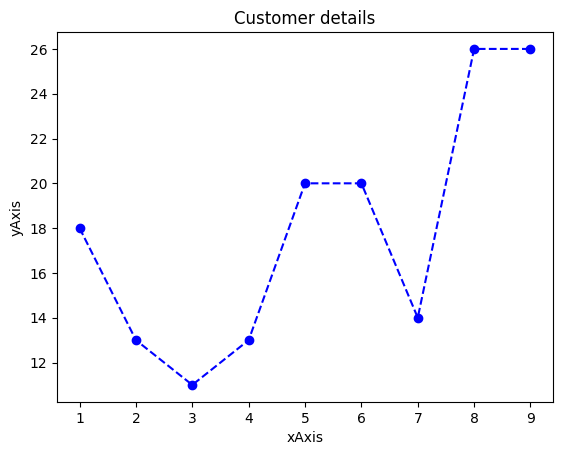

In [38]:
import matplotlib.pyplot as plt
x=[1,2,3,4,5,6,7,8,9]
y=[18,13,11,13,20,20,14,26,26]
plt.plot(x,y,linestyle="--",color="blue", marker='o')
plt.xlabel("xAxis")
plt.ylabel("yAxis")
plt.title("Customer details")
plt.show()

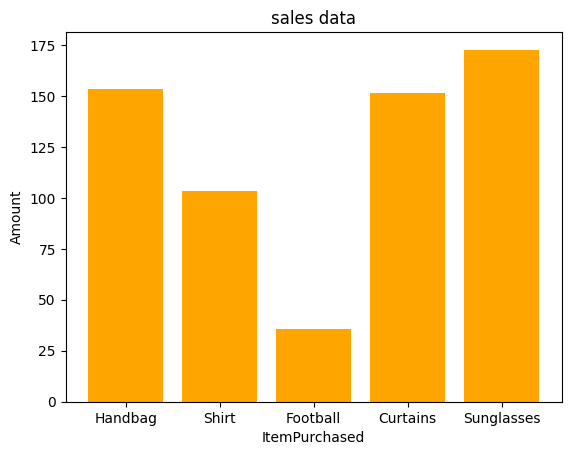

In [32]:
ItemPurchased=["Handbag","Shirt","Football","Handbag","Curtains","Sunglasses"]
Amount=[115.50,103.43,35.45,153.31,151.43,172.64]
plt.bar(ItemPurchased,Amount,color="orange")
plt.xlabel("ItemPurchased")
plt.ylabel("Amount")
plt.title("sales data")
plt.show()

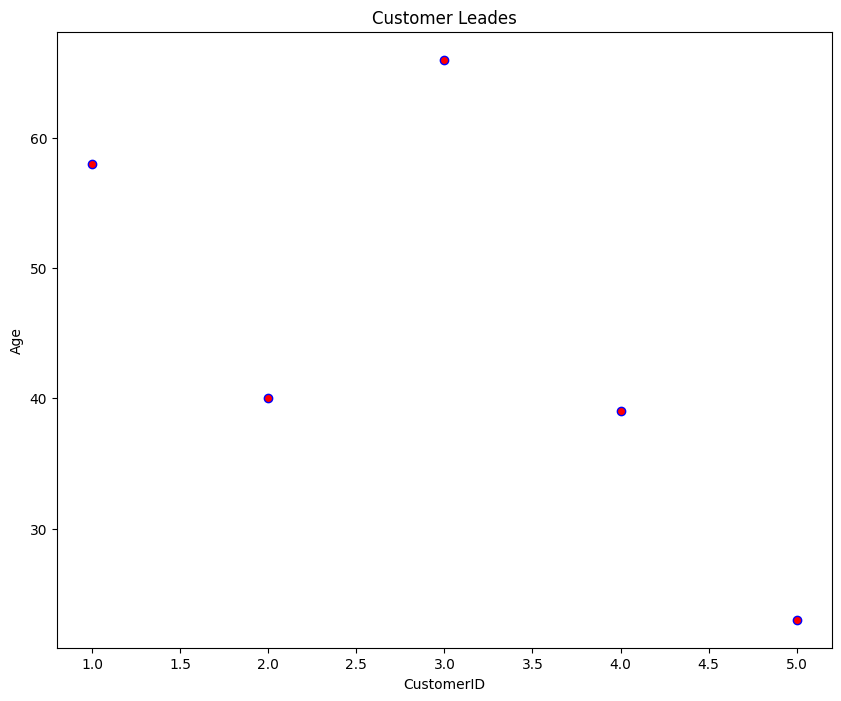

In [33]:
CustomerID=[1,2,3,4,5]
Age=[58,40,66,39,23]
plt.figure(figsize=(10,8))
plt.scatter(CustomerID,Age,color="red",edgecolor="blue")
plt.xlabel("CustomerID")
plt.ylabel("Age")
plt.title("Customer Leades")
plt.show()

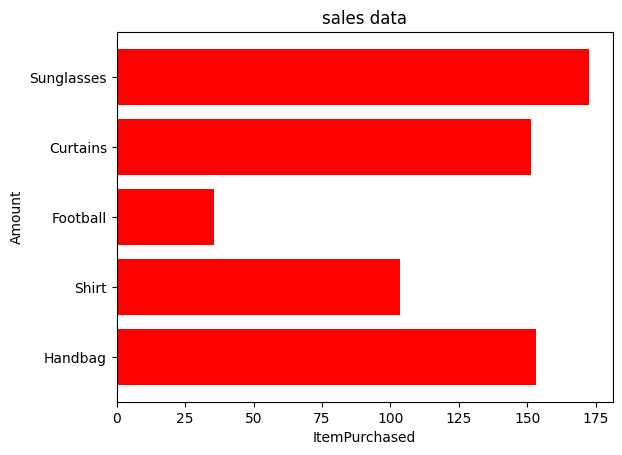

In [34]:
ItemPurchased=["Handbag","Shirt","Football","Handbag","Curtains","Sunglasses"]
Amount=[115.50,103.43,35.45,153.31,151.43,172.64]
plt.barh(ItemPurchased,Amount,color="red")
plt.xlabel("ItemPurchased")
plt.ylabel("Amount")
plt.title("sales data")
plt.show()

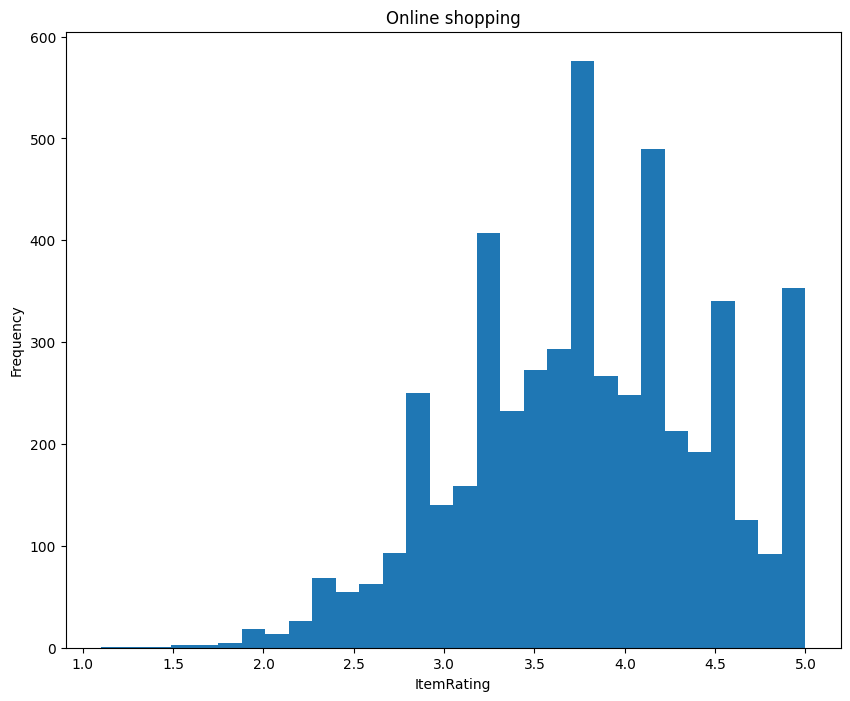

In [35]:
plt.figure(figsize=(10,8))
plt.hist(df["ItemRating"],bins=30)
plt.title("Online shopping")
plt.xlabel("ItemRating")
plt.ylabel("Frequency")
plt.show()

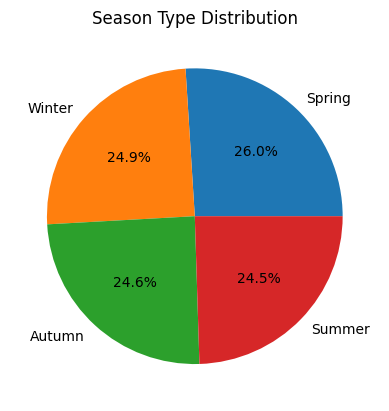

In [36]:
Season_counts=df["Season"].value_counts()
plt.pie(Season_counts,
        labels=Season_counts.index,
        autopct='%1.1f%%')
plt.title("Season Type Distribution")
plt.show()